#### 15- I denna uppgift ska vi arbeta med datasetet “car_price_dataset.csv”.

##### a) Gör ett komplett ML flöde där den beroende variabeln, 𝑦, är price. Vi vill alltså skapa en modell som kan prediktera en bils pris. Ett tips är att först göra ett enkelt flöde som fungerar, har du därefter tid kan du försöka förbättra resultaten.

In [20]:
print('hello')
# sklearn-env\Scripts\activate

hello


In [21]:
# import sys
# print(sys.executable)

In [22]:
# !{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

In [23]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_validate
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv('car_price_dataset.csv')
data.head()

,Brand;Model;Year;Engine_Size;Fuel_Type;Transmission;Mileage;Doors;Owner_Count;Price
0,Kia;Rio;2020;4.2;Diesel;Manual;289944;3;5;8501
1,Chevrolet;Malibu;2012;2.0;Hybrid;Automatic;535...
2,Mercedes;GLA;2020;4.2;Diesel;Automatic;231440;...
3,Audi;Q5;2023;2.0;Electric;Manual;160971;2;1;11780
4,Volkswagen;Golf;2003;2.6;Hybrid;Semi-Automatic...


### Oorganizerade datans kolumner.

In [25]:
data.describe()

,Brand;Model;Year;Engine_Size;Fuel_Type;Transmission;Mileage;Doors;Owner_Count;Price
count,10000
unique,10000
top,Kia;Rio;2020;4.2;Diesel;Manual;289944;3;5;8501
freq,1


In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column                                                                               Non-Null Count  Dtype
---  ------                                                                               --------------  -----
 0   Brand;Model;Year;Engine_Size;Fuel_Type;Transmission;Mileage;Doors;Owner_Count;Price  10000 non-null  str  
dtypes: str(1)
memory usage: 619.8 KB


### Inga saknade värden och en enda datatyp (string)
### All information finns på en rad i 10000 radar.
### Det behövs först att organisera datan.

In [27]:
data = pd.read_csv('car_price_dataset.csv', sep=';')
print(f'Rader: {data.shape[0]}, kolumner: {data.shape[1]}')
print(data.head())
print(f"Kolumner: {list(data.columns)}")

Rader: 10000, kolumner: 10
        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  
Kolumner: ['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']


### Steg 2: Förstå och kontrollera datasetet

Först kontrollerar vi datatyper, saknade värden och dubbletter efter vår bearbtning ovan. En regressionsmodell behöver ett numeriskt mål, medan kategoriska egenskaper måste kodas innan de kan användas av modellen. Kvalitetskontrollen är viktig eftersom felaktiga eller saknade observationer kan ge missvisande skattningar.

In [28]:
print('Datatyper och minnesanvändning:')
data.info()
print('\nSaknade värden per kolumn:')
print(data.isna().sum())
print(f'Antal dubbletter: {data.duplicated().sum()}')

Datatyper och minnesanvändning:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 1.0 MB

Saknade värden per kolumn:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64
Antal dubbletter: 0


In [29]:
print('Beskrivande statistik för numeriska variabler:')
print(data.describe().round(2))

Beskrivande statistik för numeriska variabler:
           Year  Engine_Size    Mileage     Doors  Owner_Count     Price
count  10000.00     10000.00   10000.00  10000.00     10000.00  10000.00
mean    2011.54         3.00  149239.11      3.50         2.99   8852.96
std        6.90         1.15   86322.35      1.11         1.42   3112.60
min     2000.00         1.00      25.00      2.00         1.00   2000.00
25%     2006.00         2.00   74649.25      3.00         2.00   6646.00
50%     2012.00         3.00  149587.00      3.00         3.00   8858.50
75%     2017.00         4.00  223577.50      4.00         4.00  11086.50
max     2023.00         5.00  299947.00      5.00         5.00  18301.00


### Steg 3: Definiera målvariabel och dela data

`Price` är den beroende variabeln, $y$, och övriga kolumner används som förklarande variabler, $X$. Vi delar data i träningsdata och testdata. Träningsdata används för att lära modellens parametrar, medan testdata används först efter träningen för att uppskatta generaliseringsförmågan på nya bilar.

In [30]:
X = data.drop(columns='Price')
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count']
categorical_features = ['Brand', 'Model', 'Fuel_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

print(f'Träningsdata: {X_train.shape[0]} rader')
print(f'Testdata: {X_test.shape[0]} rader')

Träningsdata: 8000 rader
Testdata: 2000 rader


### Steg 4: Träna och jämför regressionsmodeller

Eftersom `Price` är ett kontinuerligt numeriskt värde använder vi regression. Ridge-regression ger en linjär referensmodell med regularisering, medan Random Forest kan modellera icke-linjära samband och interaktioner. Förbehandlingen placeras i varje pipeline så att kategorisk kodning och skalning endast lärs från respektive träningsdel.

In [31]:
candidate_models = {
    'Ridge': Ridge(alpha=10.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    for name, model in candidate_models.items()
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
}

cv_rows = []
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({
        'Model': name,
        'CV R2': scores['test_R2'].mean(),
        'CV MAE': -scores['test_MAE'].mean(),
        'CV RMSE': -scores['test_RMSE'].mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values('CV R2', ascending=False)
    .reset_index(drop=True)
)
print('Korsvalidering på träningsdata:')
print(cv_results.round(3).to_string(index=False))

best_name = cv_results.loc[0, 'Model']
best_model = pipelines[best_name]
best_model.fit(X_train, y_train)
print(f'\nVald modell: {best_name}')

Korsvalidering på träningsdata:
        Model  CV R2  CV MAE  CV RMSE
        Ridge  0.999  27.891   87.507
Random Forest  0.987 272.840  353.353

Vald modell: Ridge


### Steg 5: Utvärdera slutmodellen på testdata

Vi använder tre kompletterande mått: MAE är det genomsnittliga absoluta felet i prisets enhet, RMSE straffar stora fel kraftigare och $R^2$ anger hur stor del av variationen i pris som modellen förklarar. Testresultaten ska bara beräknas efter att modellvalet är klart, annars riskerar utvärderingen att bli optimistisk.

Mått  Värde
 MAE 23.482
RMSE 65.540
  R2  1.000

Exempel på prediktioner:
 Verkligt pris  Predikterat pris
          2000            1704.0
         11164           11143.0
         14630           14591.0
          7334            7355.0
         10127           10144.0
          7195            7222.0
          8292            8293.0
          6229            6270.0
          5776            5805.0
          4979            5011.0


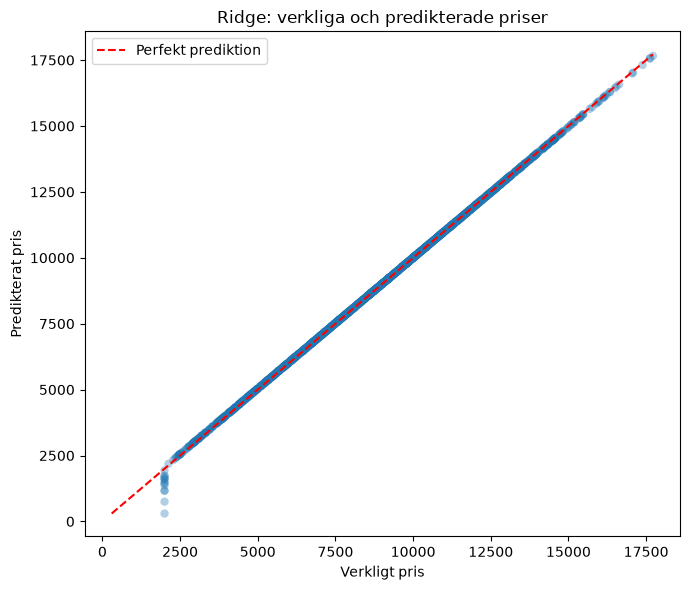

In [32]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    'Mått': ['MAE', 'RMSE', 'R2'],
    'Värde': [mae, rmse, r2],
})
print(test_metrics.round(3).to_string(index=False))

predictions = pd.DataFrame({
    'Verkligt pris': y_test.to_numpy(),
    'Predikterat pris': y_pred,
})
print('\nExempel på prediktioner:')
print(predictions.head(10).round(0).to_string(index=False))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.35, edgecolors='none')
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', label='Perfekt prediktion')
plt.xlabel('Verkligt pris')
plt.ylabel('Predikterat pris')
plt.title(f'{best_name}: verkliga och predikterade priser')
plt.legend()
plt.tight_layout()
plt.show()

##### b) Gör en applikation med hjälp av Streamlit där användaren kan mata in olika uppgifter om en bil och därefter få ett predikterat pris.

### Steg 6: Bygg en Streamlit-applikation

Streamlit ger ett enkelt webbgränssnitt för att samla in nya observationer. Applikationen måste använda exakt samma kolumnnamn, kategorier och förbehandling som modellen såg under träningen. Annars kan skillnader mellan träningsdata och användarinmatning ge felaktiga eller omöjliga prediktioner.

Filen `car_price_app.py` innehåller applikationen. Starta den från denna mapp med:

```text
streamlit run car_price_app.py
```

In [33]:
# Applikationen finns i car_price_app.py.
# Kör den i terminalen med: streamlit run car_price_app.py
print('Streamlit-applikationen är redo att startas från car_price_app.py.')

Streamlit-applikationen är redo att startas från car_price_app.py.


##### c) Det du gjort i denna uppgift, hade det kunnat användas i verkligheten? Till vad i sådana fall?

### Reflektion och verklig användning

Ja, metoden kan användas som beslutsstöd vid exempelvis värdering av begagnade bilar, lagerplanering hos bilhandlare, prisförslag på en marknadsplats eller som ett underlag vid inköp. En användare matar in bilens egenskaper och får en konsekvent prisuppskattning.

I verklig drift krävs dock mer än ett högt testresultat. Datasetet bör innehålla aktuella och representativa marknadspriser, geografiska faktorer, utrustningsnivå, servicehistorik och bilens skick. Modellen bör följas upp över tid eftersom bilmarknaden förändras, och prediktionerna bör kompletteras med osäkerhetsintervall eller mänsklig granskning. Eftersom detta dataset är syntetiskt ska resultaten främst ses som en metoddemonstration, inte som en färdig kommersiell värdering.

Modellen som används i Streamlit tränas om på hela datasetet efter att modellvalet har gjorts. Det är en vanlig produktionsstrategi: testmängden används först för en ärlig slutkontroll, och därefter kan alla tillgängliga historiska träningsobservationer utnyttjas innan modellen används på nya indata.